In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Analise de imagens tiradas a 10fps

In [2]:
dataset_wo = pd.read_csv('/home/aki/Desktop/old_cuscobot/dataset_20260126_084725(W)/sensor_data/encoder.csv', header=None)
dataset_gt = pd.read_csv('/home/aki/Desktop/old_cuscobot/dataset_20260126_084725(W)/sensor_data/vrs_gps.csv', header=None)
dataset_vo = pd.read_csv('/home/aki/Desktop/old_cuscobot/dataset_20260126_084725(W)/sensor_data/stereo_stamp.csv', header=None)

In [3]:
dataset_wo

,0,1,2
0,1769428051341548781,0,0
1,1769428051390671835,0,0
2,1769428051439872889,-2,1
3,1769428051489026110,-8,9
4,1769428051542168667,-15,17
...,...,...,...
1770,1769428150899904907,11398,8921
1771,1769428150958384067,11398,8921
1772,1769428151014626115,11398,8921
1773,1769428151072104719,11398,8921


Average FPS: 1.778771912361652


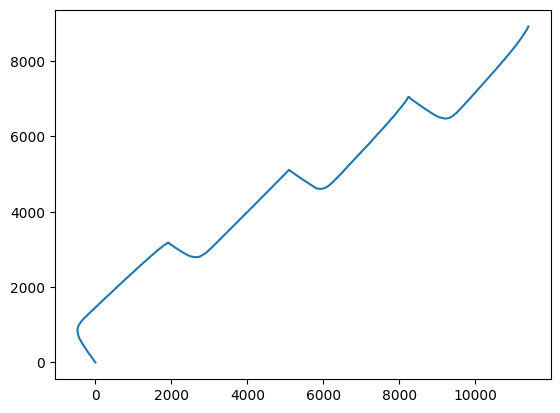

In [4]:
# WHEEL ODOMETRY
sub = 0
for i in range(1, len(dataset_wo[0])):
    sub += dataset_wo[0][i] - dataset_wo[0][i-1]

print("Average FPS:",1/(sub/len(dataset_wo[0]) * 10e-9))

plt.plot(dataset_wo[1], dataset_wo[2], label='WO')

In [5]:
dataset_vo

,0
0,1769428050376793055
1,1769428050475940174
2,1769428050575087014
3,1769428050674892563
4,1769428050774909208
...,...
987,1769428150674965799
988,1769428150775014588
989,1769428150874996075
990,1769428150975082255


0.9851198676676454


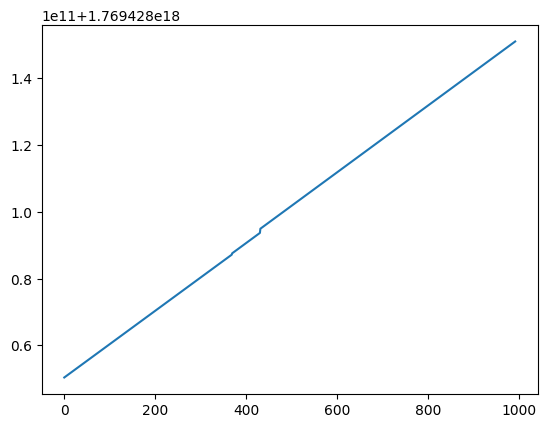

In [6]:
# VISUAL ODOMETRY

sub = 0
for i in range(1, len(dataset_vo[0])):
    sub += dataset_vo[0][i] - dataset_vo[0][i-1]

print(1/(sub/len(dataset_vo[0]) * 10e-9))

plt.plot(dataset_vo[0], label='VO')

In [7]:
dataset_gt

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1769428049228037899,0,0,-0.331690,1.048090,3.431441,0,0,0,0,0,0,1,94.871808
1,1769428049296356363,0,0,-0.326087,1.025545,3.360004,0,0,0,0,0,0,1,96.273000
2,1769428049365955862,0,0,-0.326087,1.025545,3.360004,0,0,0,0,0,0,1,96.273000
3,1769428049434382842,0,0,-0.326087,1.025545,3.360004,0,0,0,0,0,0,1,96.273000
4,1769428049500577280,0,0,-0.334168,1.054365,3.449823,0,0,0,0,0,0,1,95.457835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,1769428150820776342,0,0,-0.382320,0.777735,3.483310,0,0,0,0,0,0,1,-99.293011
1427,1769428150889632761,0,0,-0.385022,0.777699,3.483149,0,0,0,0,0,0,1,-99.270981
1428,1769428150957803433,0,0,-0.387674,0.772908,3.465736,0,0,0,0,0,0,1,-102.293912
1429,1769428151026201299,0,0,-0.393815,0.778363,3.496508,0,0,0,0,0,0,1,-102.070801


In [8]:
dataset_gt

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1769428049228037899,0,0,-0.331690,1.048090,3.431441,0,0,0,0,0,0,1,94.871808
1,1769428049296356363,0,0,-0.326087,1.025545,3.360004,0,0,0,0,0,0,1,96.273000
2,1769428049365955862,0,0,-0.326087,1.025545,3.360004,0,0,0,0,0,0,1,96.273000
3,1769428049434382842,0,0,-0.326087,1.025545,3.360004,0,0,0,0,0,0,1,96.273000
4,1769428049500577280,0,0,-0.334168,1.054365,3.449823,0,0,0,0,0,0,1,95.457835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,1769428150820776342,0,0,-0.382320,0.777735,3.483310,0,0,0,0,0,0,1,-99.293011
1427,1769428150889632761,0,0,-0.385022,0.777699,3.483149,0,0,0,0,0,0,1,-99.270981
1428,1769428150957803433,0,0,-0.387674,0.772908,3.465736,0,0,0,0,0,0,1,-102.293912
1429,1769428151026201299,0,0,-0.393815,0.778363,3.496508,0,0,0,0,0,0,1,-102.070801


Average FPS: 1.4047873462657252


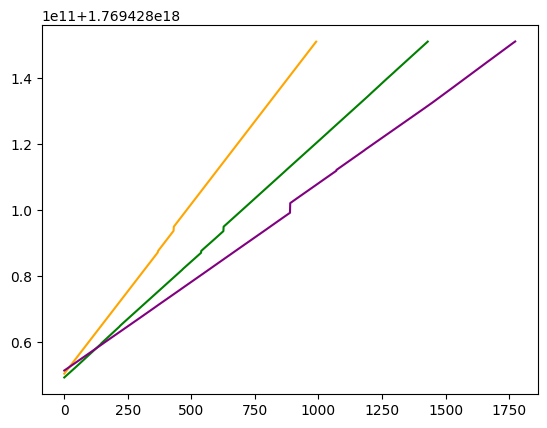

In [9]:
# GROUND TRUTH
sub = 0
for i in range(1, len(dataset_gt[0])):
    sub += dataset_gt[0][i] - dataset_gt[0][i-1]

print("Average FPS:", 1/(sub/len(dataset_gt[0]) * 10e-9))

plt.plot(dataset_gt[0], label='GT', color='green')
plt.plot(dataset_vo[0], label='VO', color='orange')
plt.plot(dataset_wo[0], label='WO', color='purple') 

In [10]:
timestamps_gt = np.array(dataset_gt[0])
timestamps_vo = np.array(dataset_vo[0])
timestamps_wo = np.array(dataset_wo[0])

# Diference between consecutive timestamps
diffs_gt = np.diff(timestamps_gt)
diffs_wo = np.diff(timestamps_wo)
diffs_vo = np.diff(timestamps_vo)

# Limiar maximum
limiar_gt = 1.5 * np.mean(diffs_gt)
limiar_wo = 1.5 * np.mean(diffs_wo)
limiar_vo = 1.5 * np.mean(diffs_vo)

# Identifie outliers or where there are missing data
outliers_gt = np.where(diffs_gt > limiar_gt)[0]
outliers_wo = np.where(diffs_wo > limiar_wo)[0]
outliers_vo = np.where(diffs_vo > limiar_vo)[0]

print("Outliers in GT timestamps at indices:", outliers_gt)
print("Outliers in WO timestamps at indices:", outliers_wo)
print("Outliers in VO timestamps at indices:", outliers_vo)

Outliers in GT timestamps at indices: [144 217 538 626]
Outliers in WO timestamps at indices: [ 888 1070 1181]
Outliers in VO timestamps at indices: [368 430]


Timestamp GT: 08:47:39
Timestamp GT: 08:47:44
Timestamp GT: 08:48:07
Timestamp GT: 08:48:13
Timestamp WO: 08:48:19
Timestamp WO: 08:48:31
Timestamp WO: 08:48:38
Timestamp VO: 08:48:07
Timestamp VO: 08:48:13


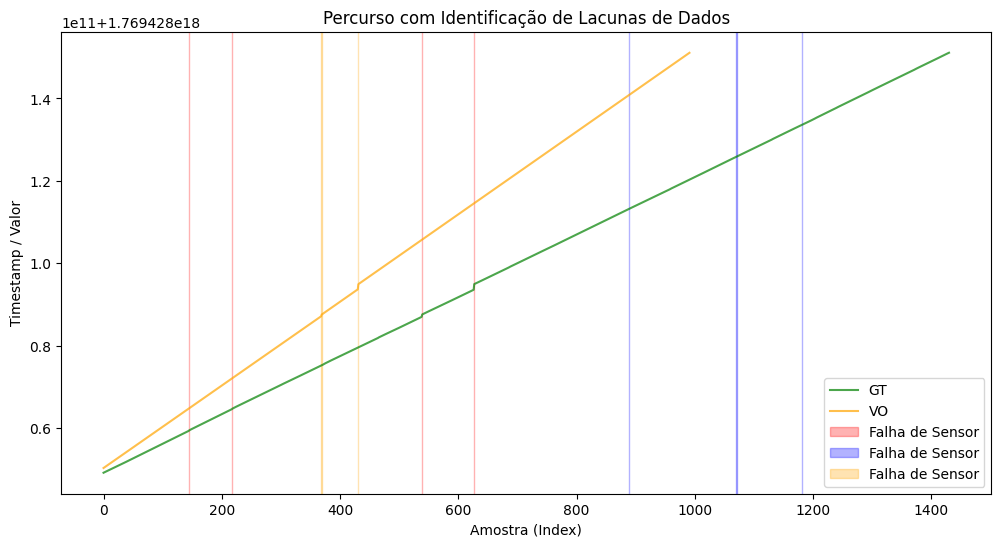

In [11]:
from datetime import datetime


plt.figure(figsize=(12, 6))

# Plot normal dos seus dados
plt.plot(range(len(dataset_gt)), dataset_gt[0], label='GT', color='green', alpha=0.7)
plt.plot(range(len(dataset_vo)), dataset_vo[0], label='VO', color='orange', alpha=0.7)

# Destacar as falhas
for idx in outliers_gt:
    # Marca o início e o fim da falha no eixo X
    plt.axvspan(idx, idx+1, color='red', alpha=0.3, label='Falha de Sensor' if idx == outliers_gt[0] else "")
    print("Timestamp GT:", datetime.fromtimestamp(dataset_gt[0][idx] / 1e9).strftime('%H:%M:%S'))

for idx in outliers_wo:
    plt.axvspan(idx, idx+1, color='blue', alpha=0.3, label='Falha de Sensor' if idx == outliers_wo[0] else "")
    print("Timestamp WO:", datetime.fromtimestamp(dataset_wo[0][idx] / 1e9).strftime('%H:%M:%S'))

for idx in outliers_vo:
    plt.axvspan(idx, idx+1, color='orange', alpha=0.3, label='Falha de Sensor' if idx == outliers_vo[0] else "")
    print("Timestamp VO:", datetime.fromtimestamp(dataset_vo[0][idx] / 1e9).strftime('%H:%M:%S'))

plt.title("Percurso com Identificação de Lacunas de Dados")
plt.xlabel("Amostra (Index)")
plt.ylabel("Timestamp / Valor")
plt.legend()
plt.show()

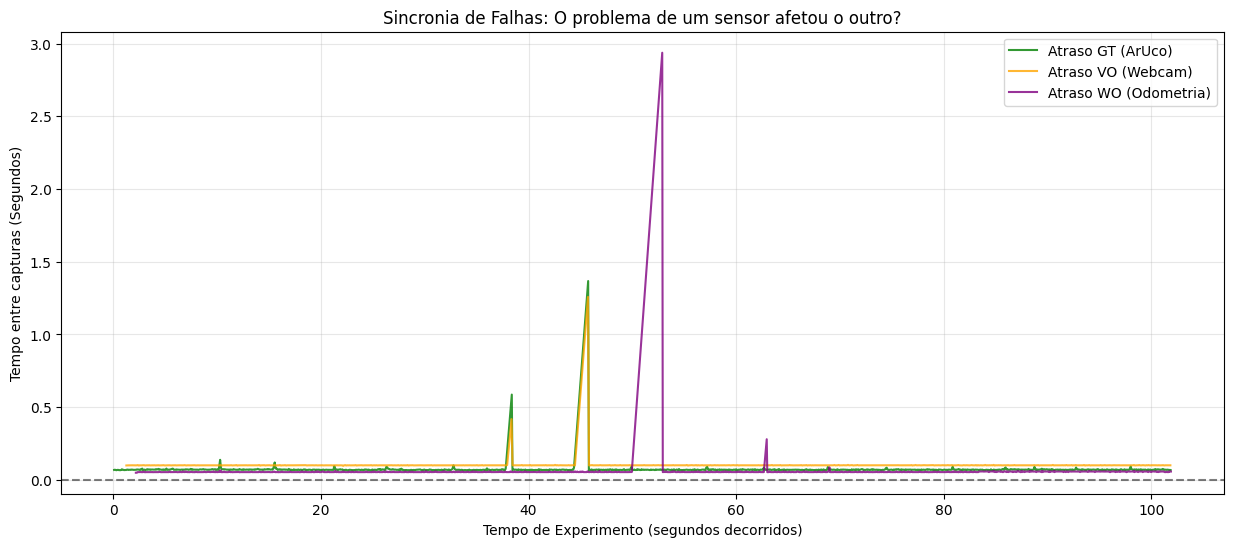

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Converter todos os timestamps para segundos (float)
time_gt = np.array(dataset_gt[0]) / 1e9
time_vo = np.array(dataset_vo[0]) / 1e9
time_wo = np.array(dataset_wo[0]) / 1e9

# 2. Definir o "Tempo Zero" (O exato momento em que o experimento começou)
t0 = min(time_gt[0], time_vo[0], time_wo[0])

# Subtrair o T0 para que o eixo X comece em 0s, 1s, 2s... (Tempo de percurso)
t_gt_relativo = time_gt - t0
t_vo_relativo = time_vo - t0
t_wo_relativo = time_wo - t0

# 3. Calcular os intervalos de tempo (Delta T) entre as amostras de cada sensor
diff_gt = np.diff(t_gt_relativo)
diff_vo = np.diff(t_vo_relativo)
diff_wo = np.diff(t_wo_relativo)

# 4. Criar o gráfico
plt.figure(figsize=(15, 6))

# Plotar os intervalos de cada sensor. 
# Usamos [1:] no eixo X porque a função diff reduz o array em 1 elemento.
plt.plot(t_gt_relativo[1:], diff_gt, label='Atraso GT (ArUco)', color='green', alpha=0.8)
plt.plot(t_vo_relativo[1:], diff_vo, label='Atraso VO (Webcam)', color='orange', alpha=0.8)
plt.plot(t_wo_relativo[1:], diff_wo, label='Atraso WO (Odometria)', color='purple', alpha=0.8)

# Linha de referência (o ideal é que os valores fiquem próximos a zero)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.title("Sincronia de Falhas: O problema de um sensor afetou o outro?")
plt.xlabel("Tempo de Experimento (segundos decorridos)")
plt.ylabel("Tempo entre capturas (Segundos)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# No início do seu script de análise:
t0 = dataset_gt[0][0] # Primeiro timestamp do experimento

# No seu print dentro do loop:
tempo_relativo_gt = (dataset_gt[0][idx] - t0) / 1e9
print(f"Falha aos {tempo_relativo_gt:.2f} segundos de percurso")
print(f"Atraso real (Lag): {(dataset_gt[0][idx] - dataset_vo[0][idx]) / 1e9:.4f} s")

Falha aos 30.33 segundos de percurso
Atraso real (Lag): -14.1446 s


In [14]:
time = 1769428126329065630
hours = datetime.fromtimestamp(time / 1e9)
hora_formatada = hours.strftime('%H:%M:%S')
print("Hora formatada:", hora_formatada)
# O tempo esta na hora que foi salva, nao na hora que foi processada
# O datalock parece estar com problema travando ambas as cameras
# Problema de timestamp, os timestamps do gt estao errados, sao salvos na hora final de salvamento apenas e nao na hora que foi capturado



Hora formatada: 08:48:46


In [15]:
from datetime import datetime

# verificação de timestamp em formato de horas no dia
print("Primeiro timestamp GT:", dataset_gt[0][0])
print("Primeiro timestamp GT em horas:", dataset_gt[0][0] / 1e9 )
# 3. Converter para data e hora local
data_hora = datetime.fromtimestamp(dataset_gt[0][0] / 1e9)

# 4. Formatar como string (Hora:Minuto:Segundo)
hora_formatada = data_hora.strftime('%H:%M:%S')
print("Primeiro timestamp GT em horas formatado:", hora_formatada)


Primeiro timestamp GT: 1769428049228037899
Primeiro timestamp GT em horas: 1769428049.2280378
Primeiro timestamp GT em horas formatado: 08:47:29


In [16]:
from datetime import datetime

# verificação de timestamp em formato de horas no dia
print("Primeiro timestamp VO:", dataset_vo[0][0])
print("Primeiro timestamp VO em horas:", dataset_vo[0][0] / 1e9 )
# 3. Converter para data e hora local
data_hora = datetime.fromtimestamp(dataset_vo[0][0] / 1e9)

# 4. Formatar como string (Hora:Minuto:Segundo)
hora_formatada = data_hora.strftime('%H:%M:%S')
print("Primeiro timestamp VO em horas formatado:", hora_formatada)

Primeiro timestamp VO: 1769428050376793055
Primeiro timestamp VO em horas: 1769428050.3767931
Primeiro timestamp VO em horas formatado: 08:47:30


In [17]:
from datetime import datetime

# verificação de timestamp em formato de horas no dia
print("Primeiro timestamp WO:", dataset_wo[0][0])
print("Primeiro timestamp WO em horas:", dataset_wo[0][0] / 1e9 )
# 3. Converter para data e hora local
data_hora = datetime.fromtimestamp(dataset_wo[0][0] / 1e9)

# 4. Formatar como string (Hora:Minuto:Segundo)
hora_formatada = data_hora.strftime('%H:%M:%S')
print("Primeiro timestamp WO em horas formatado:", hora_formatada)

Primeiro timestamp WO: 1769428051341548781
Primeiro timestamp WO em horas: 1769428051.3415487
Primeiro timestamp WO em horas formatado: 08:47:31


=== Resumo: Ground Truth (ArUco) ===
Total de Amostras : 1431
Tempo de Execução : 101.87 segundos
Frequência Média  : 14.05 Hz (FPS)

=== Resumo: Visual Odometry (Webcam) ===
Total de Amostras : 992
Tempo de Execução : 100.70 segundos
Frequência Média  : 9.85 Hz (FPS)

=== Resumo: Odometria (Encoder) ===
Total de Amostras : 1775
Tempo de Execução : 99.79 segundos
Frequência Média  : 17.79 Hz (FPS)



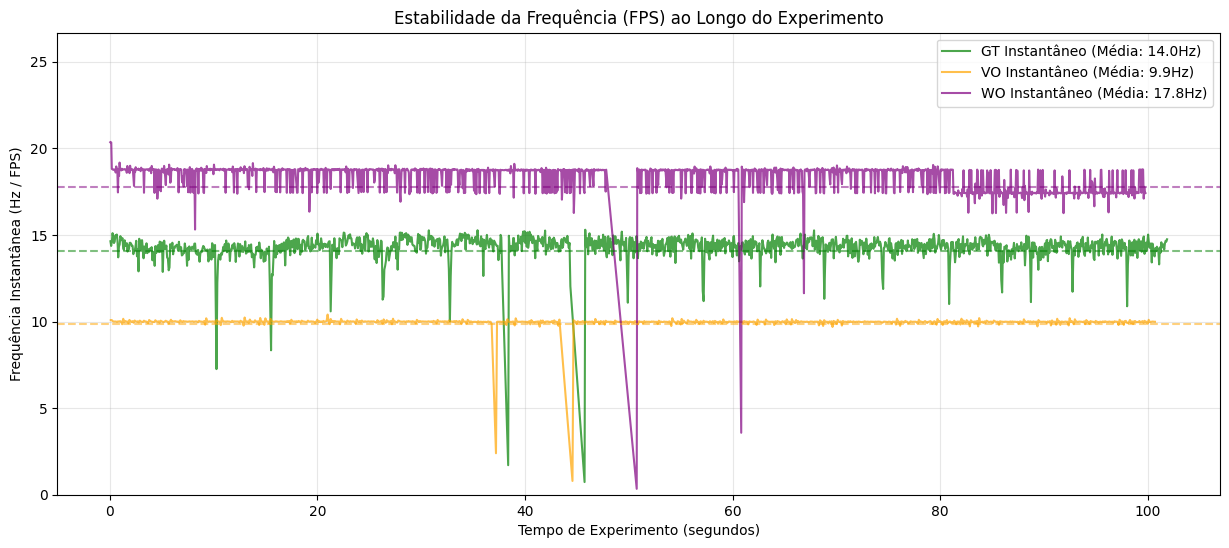

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def analisar_frequencia(timestamps, nome_sensor):
    # 1. Converter para array NumPy e para Segundos (dividindo por 1e9)
    ts_sec = np.array(timestamps) / 1e9
    
    # -----------------------------------------
    # CÁLCULO DA FREQUÊNCIA MÉDIA
    # -----------------------------------------
    tempo_total = ts_sec[-1] - ts_sec[0] # Tempo do último frame - primeiro frame
    total_amostras = len(ts_sec)
    
    freq_media = total_amostras / tempo_total
    
    print(f"=== Resumo: {nome_sensor} ===")
    print(f"Total de Amostras : {total_amostras}")
    print(f"Tempo de Execução : {tempo_total:.2f} segundos")
    print(f"Frequência Média  : {freq_media:.2f} Hz (FPS)\n")
    
    # -----------------------------------------
    # CÁLCULO DA FREQUÊNCIA INSTANTÂNEA
    # -----------------------------------------
    # Calcula a diferença de tempo entre cada frame
    deltas = np.diff(ts_sec)
    
    # Proteção: Se dois timestamps forem iguais (delta=0), evita erro de divisão por zero
    deltas = np.where(deltas == 0, 1e-9, deltas)
    
    # Frequência = 1 / Tempo
    freq_instantanea = 1.0 / deltas
    
    # Tempo relativo para o eixo X do gráfico (começando do zero)
    tempo_relativo = ts_sec[1:] - ts_sec[0] 
    
    return tempo_relativo, freq_instantanea, freq_media

# ==========================================
# EXECUTANDO A ANÁLISE
# ==========================================
# (Assumindo que dataset_gt[0], dataset_vo[0] e dataset_wo[0] já estão carregados)

t_gt, fps_gt, med_gt = analisar_frequencia(dataset_gt[0], "Ground Truth (ArUco)")
t_vo, fps_vo, med_vo = analisar_frequencia(dataset_vo[0], "Visual Odometry (Webcam)")
t_wo, fps_wo, med_wo = analisar_frequencia(dataset_wo[0], "Odometria (Encoder)")

# ==========================================
# PLOTANDO O GRÁFICO DE FPS AO LONGO DO TEMPO
# ==========================================
plt.figure(figsize=(15, 6))

# Plota a linha de cada sensor
plt.plot(t_gt, fps_gt, label=f'GT Instantâneo (Média: {med_gt:.1f}Hz)', color='green', alpha=0.7)
plt.plot(t_vo, fps_vo, label=f'VO Instantâneo (Média: {med_vo:.1f}Hz)', color='orange', alpha=0.7)
plt.plot(t_wo, fps_wo, label=f'WO Instantâneo (Média: {med_wo:.1f}Hz)', color='purple', alpha=0.7)

# Adiciona linhas pontilhadas mostrando a média de cada um
plt.axhline(y=med_gt, color='green', linestyle='--', alpha=0.5)
plt.axhline(y=med_vo, color='orange', linestyle='--', alpha=0.5)
plt.axhline(y=med_wo, color='purple', linestyle='--', alpha=0.5)

# Configurações visuais do gráfico
plt.title("Estabilidade da Frequência (FPS) ao Longo do Experimento")
plt.xlabel("Tempo de Experimento (segundos)")
plt.ylabel("Frequência Instantânea (Hz / FPS)")
# Limita o eixo Y para remover picos bizarros causados por variações de nanosegundos do SO
plt.ylim(0, max(med_gt, med_vo, med_wo) * 1.5) 
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()